In [1]:
import torch, os, pickle, math
import os.path as osp
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

if torch.cuda.is_available() and torch.cuda.device_count()>=1:
    device = 'cuda'
else:
    device = 'cpu'

/tmp/ipykernel_559989/3853979743.py:7: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


# Connecting the optical and IR

Galaxies are often modeled as independent components, each emitting in distinct wavelength ranges. This assumption is a result of the assumption that the different physical components, which have different spectral signatures, are only weakly correlated. However, this assumption overlooks the deep, underlying physical couplings between components. 

By leveraging these couplings, we can predict IR photometry directly from optical spectra with remarkable accuracy. This capability is transformative for our understanding of galaxies, because it demonstrates that the different physical components of galaxies are in fact **extremely tightly coupled**.

Traditional spectrum (SED) fitting models struggle to capture these cross-wavelength relationships, exactly because they ignore the physical relations that drive this coherent picture of galaxy evolution.

With the wealth of optical spectra, and upcoming IR photometry, available from large-scale surveys, this approach opens new avenues for galaxy evolution studies. 

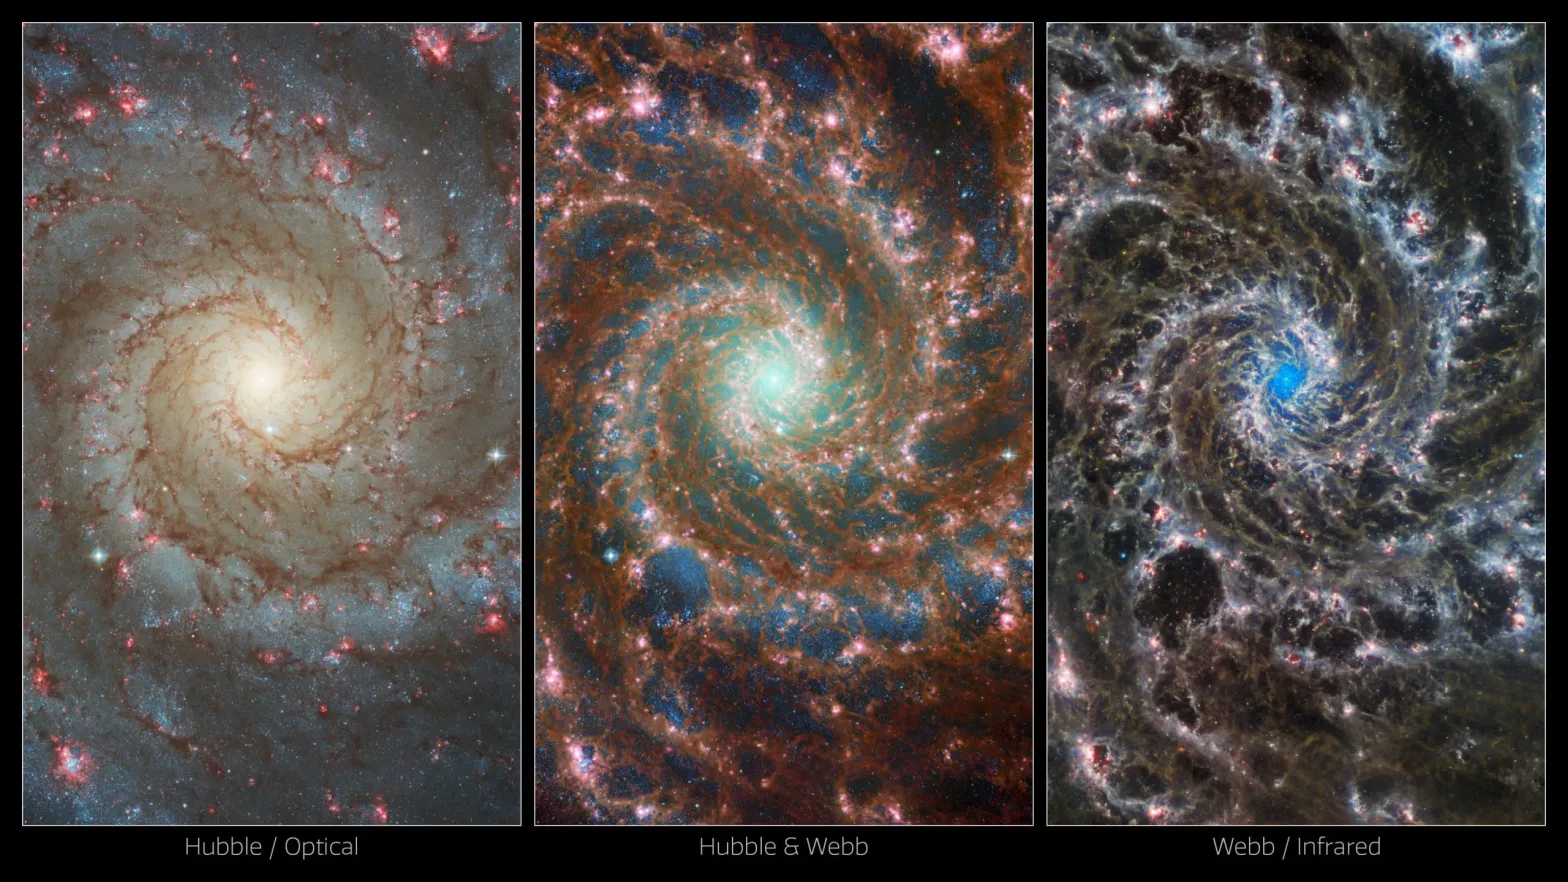

#### A demonstration of a galaxy imaged in both the optical and IR (credit: NASA). Some correlations are obvious, but predicting one from the other was an unsettled question until now.

# Predicting WISE Photometry from SDSS Optical Spectra Using the ``spender`` Autoencoder

This notebook demonstrates the process of predicting WISE photometry from optical spectra utilizing the ``spender`` autoencoder, as detailed in [Melchior et al. 2022](https://arxiv.org/abs/2211.07890) and [Liang et al. 2023](https://arxiv.org/abs/2302.02496). The notebook is divided into two main sections:

1. **Autoencoding Optical Spectra**: This section illustrates how the ``spender`` autoencoder processes and compresses optical spectra into a latent representation. [Click here for the auto-encoding step only.](#autoencoding-optical-spectra)


2. **Predicting WISE Photometry**: Building upon the autoencoded spectra, this section demonstrates the methodology to predict WISE photometric measurements. [Click here to skip the auto-encoding step.](#predicting-wise-photometry)

*Note*: As always with ML, the results may not fully replicate the findings of Jespersen et al. 2025, but this notebook should effectively demonstrate the method.

### Let's get started!

<a id="autoencoding-optical-spectra"></a>
## Autoencoding Optical Spectra with ``spender``

This step is not treated extensively in the paper, but since it makes a big difference for the way that the code works, we include it here. It is also just cool.

The Princeton Astro Data Group has a lot of pre-trained models, so choose the one that fits you!

Here we pick the one that was trained on SDSS-II.

In [2]:
import spender # install with < pip install spender >
# show list of pretrained models
print(spender.hub.list())

# print out details for SDSS model from paper II
print(spender.hub.help('sdss_II')) 

# load instrument and spectrum model from the hub
sdss, model = spender.hub.load('sdss_II', map_location=torch.device(device))

# if your machine does not have GPUs, specify the device
from accelerate import Accelerator
accelerator = Accelerator(mixed_precision='fp16')
sdss, model = spender.hub.load('sdss_II', map_location=accelerator.device)

['desi_edr_galaxy', 'desi_edr_galaxy_flow', 'desi_edr_star', 'desi_edr_star_flow', 'sdss_I', 'sdss_II', 'sdss_I_superres']
Spectrum Autoencoder model for the SDSS main galaxy sample.

    This model has S=6 latents and a restframe resolution R=7000 for a maximum redshift of z_max=0.5.
    It has been trained with fidelity, similarity, and consistency losses to provide a redshift-invariant latent space.

    See spender papers for details:
        Liang at al. (2023): arXiv:2302.02496
        Melchior et al. (2022): arXiv:2211.07890
    


In [3]:
## let's make sure the model is on the GPU if availiable
if not next(model.parameters()).is_cuda and device == 'cuda':
    model = model.to(torch.device('cuda'))

We have crossmatched SDSS optical spectra with WISE photometry. The things to care about for the autoencoding step are

1. The **normalized** spectra.
2. the redshifts (z).
3. The normalization (norm). This is just a simply multiplicative factor.

Other things included are
- The weights (inverse variances) which effectively mask out sky-lines as well as having the statistical error. These are only used for training, but they're in our data file.
- The redshift error (zerr)
- The spectrum ID, ``specid``, in ``[plate, MJD, fiberID]`` format
- The wise photometry and errors (wise)

In [4]:
path = osp.expanduser('data')
save_path = path
files = os.listdir(save_path)
files = [f for f in files if 'sdss' not in f]
files = files[:1]

print(save_path+files[0])

specs = []
weights = []
zs = []
norms = []
wises = []
for f in files:
    spec, weight, z, specid, norm, zerr, wise = pickle.load(open(save_path+f, "rb"))
    specs.append(spec)
    weights.append(weight)
    
    zs.append(z)
    norms.append(norm)        
    wises.append(wise)

specs = np.vstack(specs)
weights = np.vstack(weights)

wises = np.vstack(wises)
zs = np.hstack(zs)
norms = np.hstack(norms)

/home/cj1223/../../scratch/gpfs/cj1223/sdss/dynamic_wise/WISEvariable_59.pkl


### Now we're ready to go!
Because the spectra are already normalized, I can go ahead and just throw them into and get some latent variables.

In [5]:
latents = model.encoder(torch.tensor(specs[:10], device = torch.device(device)))
latents

tensor([[-0.3171,  0.0726,  0.5567,  0.4574,  0.4019, -0.4252],
        [ 0.7361,  0.3284, -0.2020, -1.2964, -0.4381,  0.4746],
        [-0.2742,  0.0693,  0.5189,  0.4114,  0.3660, -0.3794],
        [ 0.3605,  0.0699, -0.0568, -0.3904, -0.1739,  0.0873],
        [-0.2836,  0.0666,  0.5284,  0.4225,  0.3834, -0.3981],
        [-0.2492,  0.0568,  0.4816,  0.3765,  0.3409, -0.3604],
        [-0.2459,  0.0846,  0.5280,  0.3116,  0.3493, -0.3843],
        [ 0.0263,  0.1319,  0.4000, -0.1184,  0.1679, -0.2339],
        [ 0.1935,  0.1161,  0.2029, -0.2713,  0.0165, -0.1055],
        [ 0.8542,  0.3479, -0.3853, -1.4715, -0.5763,  0.6364]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

Now we have some latents! Below is a demonstration of reconstructing spectra from the latents at the original/various redshifts, try playing with it a bit, it's a lot of fun seeing how the model extrapolates beyond the original observed wavelengths.

Of course, the model is traine at z = [0-0.5], so if you put z1 = 2, you'll get nonsense out.

In [6]:
# let's add some nice plotting stuff
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams["figure.facecolor"] = "white"
plt.rc("text", usetex=True)
plt.rc("font", family="serif",size= 28)
plt.rc("axes", linewidth=1.5)
plt.rc("axes", labelsize=28)
plt.rc("xtick", labelsize=24, direction="in")
plt.rc("ytick", labelsize=24, direction="in")
plt.rc("xtick", top=True)
plt.rc("ytick", right=True)
plt.rc("xtick.minor", visible=True)
plt.rc("ytick.minor", visible=True)
plt.rc("xtick.major",size=13, pad=4)
plt.rc("xtick.minor",size=7, pad=4)
plt.rc("ytick.major",size=13)
plt.rc("ytick.minor",size=7)
plt.rc("legend", fontsize=22)

[Text(0.5, 0, '$\\mathrm{Wavelength~[Å]}$')]

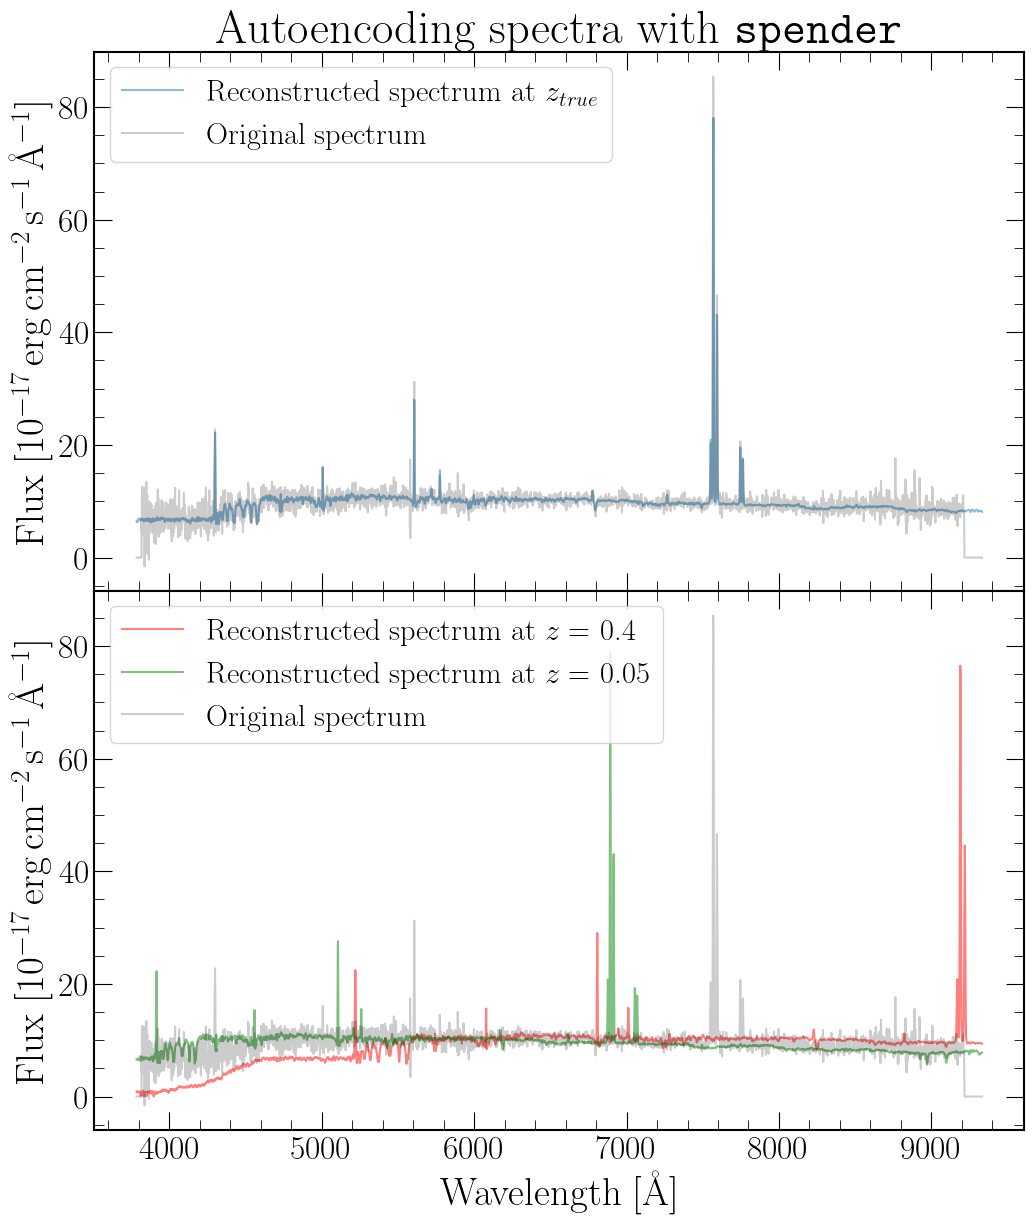

In [7]:
# wavelength in Å
wave_obs = 10 ** np.arange(3.578, 3.97, 0.0001)

# index for spectrum, change within 0-9 as you please
j = 1

# redhsift to reconstruct at
z1 = 0.4
z2 = 0.05
fig, ax = plt.subplots(figsize = (12,14), nrows = 2)
plt.subplots_adjust(hspace = 0)

s0 = specs[j]
lat = model.encoder(torch.tensor(np.vstack([s0]),  device = accelerator.device))
s = model.decoder(lat, instrument = sdss, z = torch.tensor([zs[j]], device = accelerator.device))

ax[0].plot(wave_obs, s.cpu().detach().numpy().T*norms[j], alpha = 0.5, label = r'Reconstructed spectrum at $z_{true}$')
ax[0].plot(wave_obs, s0*norms[j], 'k-', alpha = 0.2, label = 'Original spectrum')

s = model.decoder(lat, instrument = sdss, z = torch.tensor([z1], device = accelerator.device))
ax[1].plot(wave_obs, s.cpu().detach().numpy().T*norms[j], 'r-', alpha = 0.5, label = r'Reconstructed spectrum at $z = $'+f' {z1}')

s = model.decoder(lat, instrument = sdss, z = torch.tensor([z2], device = accelerator.device))
ax[1].plot(wave_obs, s.cpu().detach().numpy().T*norms[j], 'g-', alpha = 0.5, label = r'Reconstructed spectrum at $z = $'+f' {z2}')

ax[1].plot(wave_obs, s0*norms[j], 'k-', alpha = 0.2, label = 'Original spectrum')

for a in ax:
    a.legend()
    a.set(ylabel = r'$\mathrm{Flux~[10^{-17}\,erg\,cm^{-2}\,s^{-1}\,Å^{-1}]}$')

ax[0].set(title = r'$\mathrm{Autoencoding~spectra~with~}\texttt{spender}$')
ax[1].set(xlabel = r'$\mathrm{Wavelength~[Å]}$')
# fig

The main thing to notice here, is the models ability to accurately extrapolate beyond the wavelength range of the spectrum! 

This was the basis for the belief that the latents could be used to extrapolate even further!

---- But now that we the autoencoder in place, let's predict some IR photometry ----

<a id="predicting-wise-photometry"></a>
## Predicting WISE photometry

Now that we have demonstrated how to autoencode the optical spectra, let's go from the spectra to the IR photometry.

In [10]:
import pandas as pd
wise_sdss_spender = pd.read_csv(path+'sdss_wise_cross_reg0.csv')

In [12]:
phot_cols = ['w1mpro',  'w2mpro',  'w3mpro', 'w4mpro']
sig_cols = ['w1sigmpro',  'w2sigmpro',  'w3sigmpro', 'w4sigmpro']

wise_phot = wise_sdss_spender[phot_cols]
wise_phot_sig = wise_sdss_spender[sig_cols]

spender_cols = ['spender_'+f'{i}' for i in range(6)]
spender_cols+=['Z']
spender_cols+=['reg']


spender_lat = wise_sdss_spender[spender_cols]

In [32]:
import torch
import torch.nn as nn
import accelerate
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# X_train, X_test, y_train, y_test = train_test_split(spender_lat[:N], wise_phot[['w1mpro', 'w2mpro', 'w3mpro', 'w4mpro']][:N], random_state=1)

N = len(spender_lat)

data_x = spender_lat[:N].to_numpy()

data_y = wise_phot[['w1mpro', 'w2mpro', 'w3mpro', 'w4mpro']][:N]
data_sig = wise_phot_sig[['w1sigmpro', 'w2sigmpro', 'w3sigmpro', 'w4sigmpro']][:N]

dat_y = np.concatenate((data_y, data_sig), axis = 1)

ids = np.arange(len(data_x))
np.random.shuffle(ids)
train_id = ids[:int(len(ids)*0.8)] #for a random train/test set
test_id = ids[int(len(ids)*0.8):] #for a random train/test set

all_data = TensorDataset(torch.Tensor(data_x), torch.Tensor(dat_y))

train_data = all_data[train_id]
test_data = all_data[test_id]

batch_size = 512

train_loader = DataLoader(train_data, batch_size = batch_size)
test_loader = DataLoader(test_data, batch_size = batch_size)

model = nn.Sequential(
    nn.Linear(8, 20),
    nn.ReLU(),
    nn.Linear(20, 50),
    nn.ReLU(),
    nn.Linear(50, 50),
    nn.ReLU(),
    nn.Linear(50, 20),
    nn.ReLU(),
    nn.Linear(20, 4)
)

loss_fn = nn.GaussianNLLLoss()

optimizer = Adam(model.parameters(), lr = 4e-3)

accelerator = accelerate.Accelerator(mixed_precision='fp16')
model, train_loader, test_loader, optimizer = accelerator.prepare(model, train_loader, test_loader, optimizer)

In [22]:
train_loss = []
test_loss = []

n_epochs = int(5e3)
val_epoch = 10

min_loss = 10000
n_improv = 0
patience = 200

for n in tqdm(range(n_epochs)): # n_epochs can be very high, but since this is a demo, we'll keep it down. We usually trained for 2-4 e5 epochs to get our results.
    if n_improv<patience:
        t_loss = 0
        for data in train_loader:
            model.train()
            out = model(data[0])

            loss = loss_fn(out, data[1][:, :4], torch.sqrt(data[1][:, 4:]))
            t_loss+=loss

            accelerator.backward(loss)
            optimizer.step()
            optimizer.zero_grad()

        if n%val_epoch==0:
            train_loss.append(t_loss.cpu().detach())
            t_loss = 0
            for data in test_loader:
                model.eval()
                out = model(data[0])

                loss = loss_fn(out, data[1][:, :4], torch.sqrt(data[1][:, 4:]))
                t_loss += loss
            if t_loss<min_loss:
                min_loss = t_loss
                n_improv = 0
            else:
                n_improv += 1
            test_loss.append(t_loss.cpu().detach())

  0%|          | 0/5000 [00:00<?, ?it/s]

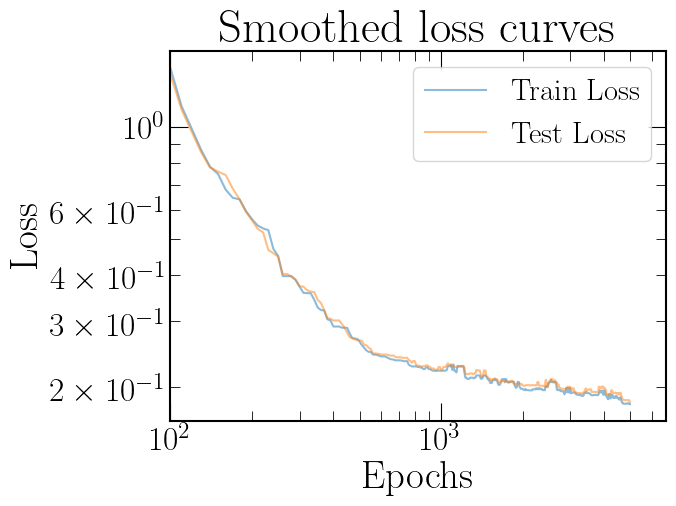

In [24]:
from scipy.signal import medfilt

smoothing = 21
fig, ax = plt.subplots()
epochs = np.arange(len(train_loss))*10
ax.plot(epochs, medfilt(train_loss, smoothing), alpha = 0.5, label = 'Train Loss')
plt.plot(epochs, medfilt(test_loss, smoothing), alpha = 0.5, label = 'Test Loss')

ax.set(yscale='log', xscale='log', xlim = (100, None), title = r'$\mathrm{Smoothed~loss~curves}$', ylabel = 'Loss', xlabel = 'Epochs')
ax.legend()

In [25]:
#################################################
### let's get the predictions on the test set ###
#################################################

y_test, pred_test, sig_test = [], [], []
for data in test_loader:
    model.eval()
    out = model(data[0])
    pred_test.append(out.cpu().detach().numpy())
    y_test.append(data[1][:,:4].cpu().detach().numpy())    
    sig_test.append(data[1][:,4:].cpu().detach().numpy())
    
y_test, y_pred, sig_test = np.vstack(y_test), np.vstack(pred_test), np.vstack(sig_test)

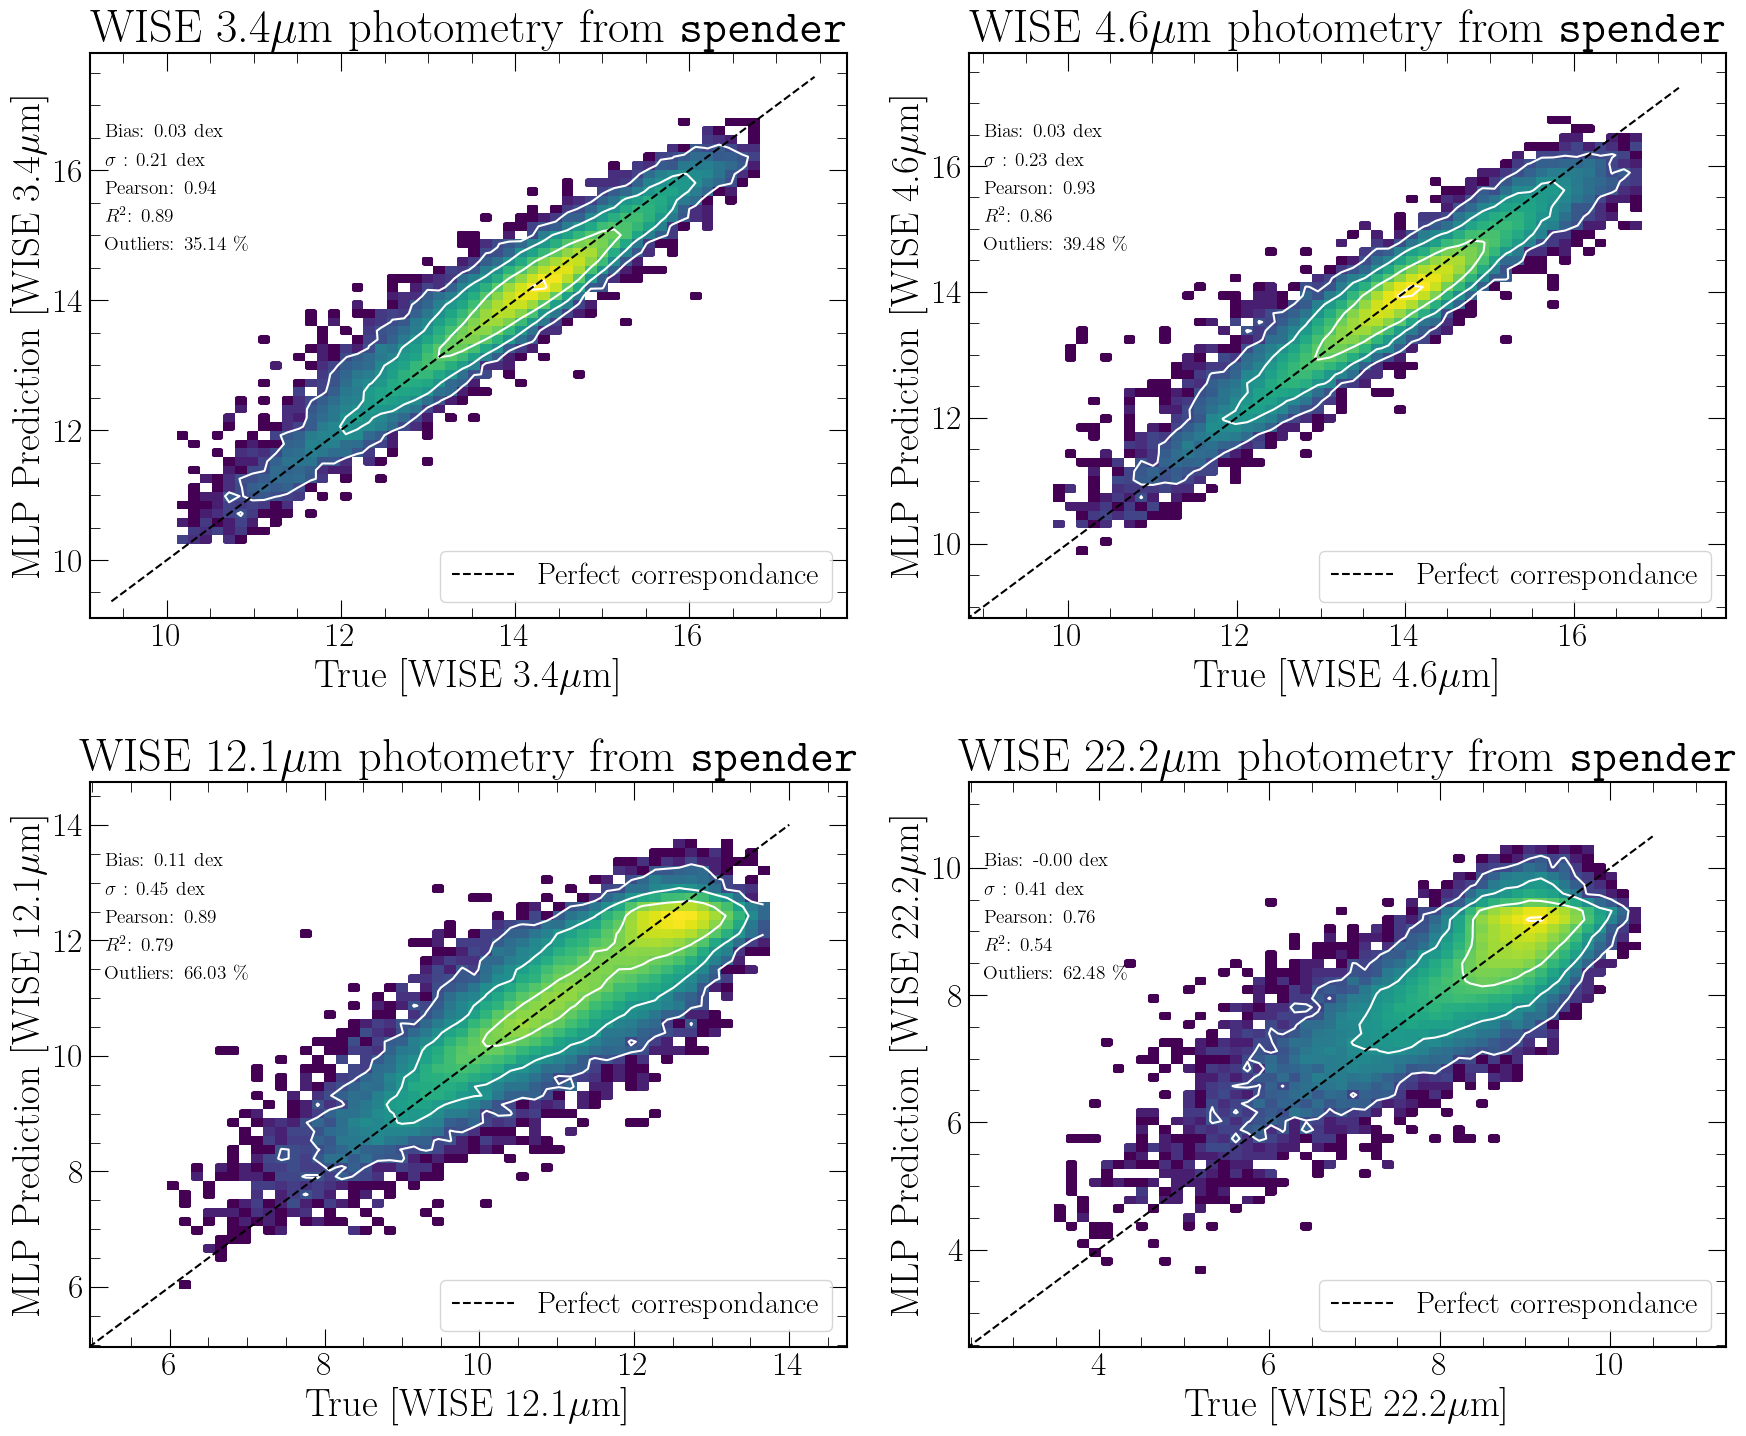

In [26]:
##################################
### let's plot our predictions ###
##################################

from sklearn.metrics import r2_score
fig, axs = plt.subplots(2, 2, figsize = (18, 15))

axs = axs.flatten()

for i in range(4):
    
    ax = axs[i]
    bins = 50
    l = 0.01
    n_contour = 4

    pred, true = y_pred[:,i], y_test[:,i]

    scatter = np.std(pred-true)
    bias = np.mean(true-pred)

    IQR = np.percentile(pred-true, [25, 75])
    scatter = (IQR[1] - IQR[0])/1.349
    bias = np.median(true-pred)

    pct = 1 - np.sum(np.abs(true-pred)<0.2)/len(true-pred)    
    r2 = r2_score(true,pred)
    rho = np.corrcoef(true,pred)[0,1]

    tot = np.hstack([true,pred])
    vals, x, y, hist = ax.hist2d(true, pred ,bins=bins, range=[np.percentile(tot, [0+l,100-l]),
                                        np.percentile(tot, [0+l,100-l])], norm=mpl.colors.LogNorm(),cmap=mpl.cm.viridis)

    names =  ['WISE 3.4$\mu$m', 'WISE 4.6$\mu$m', 'WISE 12.1$\mu$m', 'WISE 22.2$\mu$m']
    ax.set(ylabel = r'MLP Prediction '+ f'[{names[i]}]',\
           xlabel = r'True '+ f'[{names[i]}]', title = f'{names[i]}'+r' photometry from \texttt{spender}')
    l = np.percentile(tot, [0+l,100-l]) + np.array([-1, 1])
    ax.set(xlim = l, ylim = l)

    X, Y = np.meshgrid((x[1:]+x[:-1])/2, (y[1:]+y[:-1])/2)
    ax.contour(X,Y, np.log(vals.T+1), levels=n_contour, colors='white'),
    ax.plot([min(true), max(true)],[min(true), max(true)], 'k--', label='Perfect correspondance')

    xt=0.02
    yt=0.85
    dy=0.05
    font = {'weight': 'normal', 'size': 14}

    ax.text(xt,yt, f'Bias:   {bias:.2f} dex', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-dy, r'$\sigma$ : '+f'{scatter:.2f} dex', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-2*dy, r'Pearson:  '+f'{rho:.2f}', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-3*dy, r'$R^2$:  '+f'{r2:.2f}', fontdict=font, transform=ax.transAxes)
    ax.text(xt,yt-4*dy, r'Outliers:  '+f'{pct*100:.2f} \%', fontdict=font, transform=ax.transAxes)

    ax.legend(loc = 'lower right')
fig.tight_layout()

In [27]:
def IQR_sig(x):
    iqr = np.nanpercentile(x, [84, 16])
    return (iqr[0]-iqr[1])/2

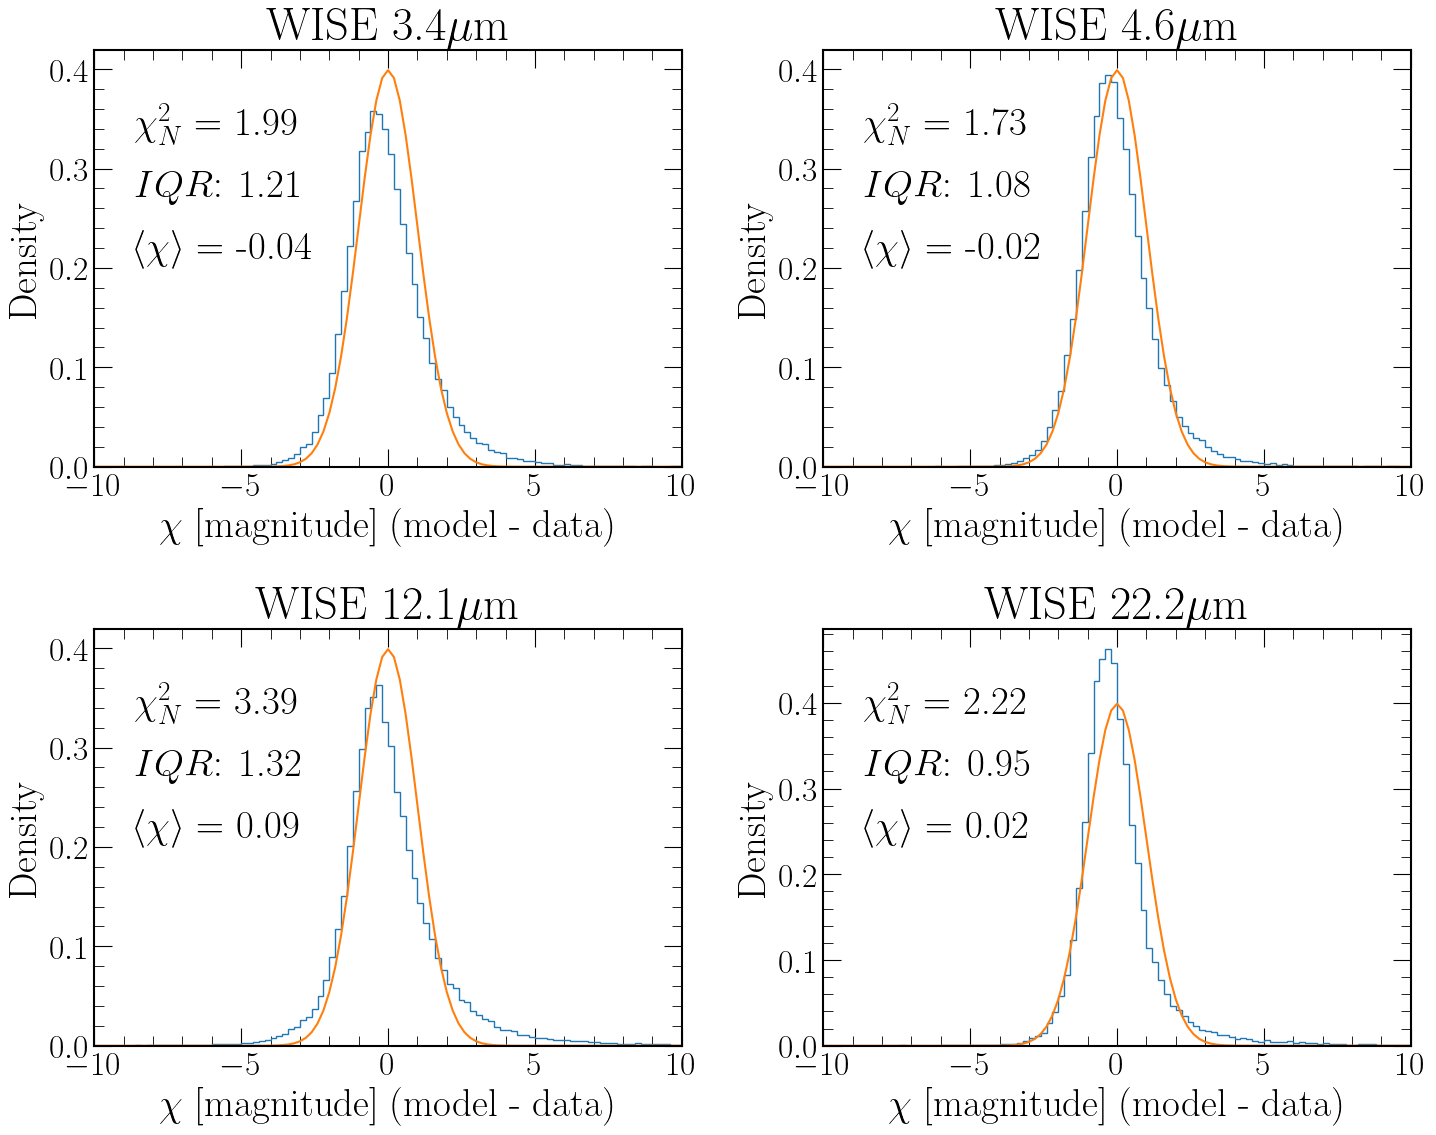

In [31]:
fig, axs = plt.subplots(2, 2, figsize = (15, 12))
axs = axs.flatten()
xt = 0.07
yt = 0.8
dy = 0.15

outlier_lim = 100
for i in range(4):
    pred, true = y_pred[:,i], y_test[:,i]
    m = sig_test[:,i]<5 #select only bands with detections
    z = (pred[m]-true[m])/np.sqrt(sig_test[m,i])
    vals, bins, _ = axs[i].hist( z, bins = 100, range = (-10, 10), histtype = 'step', density = 1);
    axs[i].set( xlim = (-10, 10), xlabel = r'$\chi$ [magnitude] (model - data)', ylabel = 'Density', title = names[i])
    axs[i].plot(bins, 1/np.sqrt(2*np.pi)*np.exp(-bins**2/2))
    axs[i].text(xt, yt, fr'$\chi^2_N$ = {sum(z[z<outlier_lim]**2)/len(z[z<outlier_lim]):.2f}', transform=axs[i].transAxes)
    axs[i].text(xt, yt-dy, fr'$IQR$: {IQR_sig(z):.2f}', transform=axs[i].transAxes)
    axs[i].text(xt, yt-2*dy, fr'$\langle \chi \rangle$ = {np.mean(z):.2f}', transform=axs[i].transAxes)
    
fig.tight_layout()

As you should be able to see, the distributions are already getting close to $\chi^2_N \approx 1$, especially in the centers, as measured by the IQR. This is much better than what spectrum fitting models can achieve!

If you turn up the length of training, and do a couple of runs to make sure that you're not hitting a weird bump in the training for the final epoch, you should get to something even closer!

If you want to make sure that everything is reproducable, use the ``np.loadtxt('data/test_ids.csv').astype(int)`` as the test set.

## No matter what, congratulations on connecting the optical and the IR!

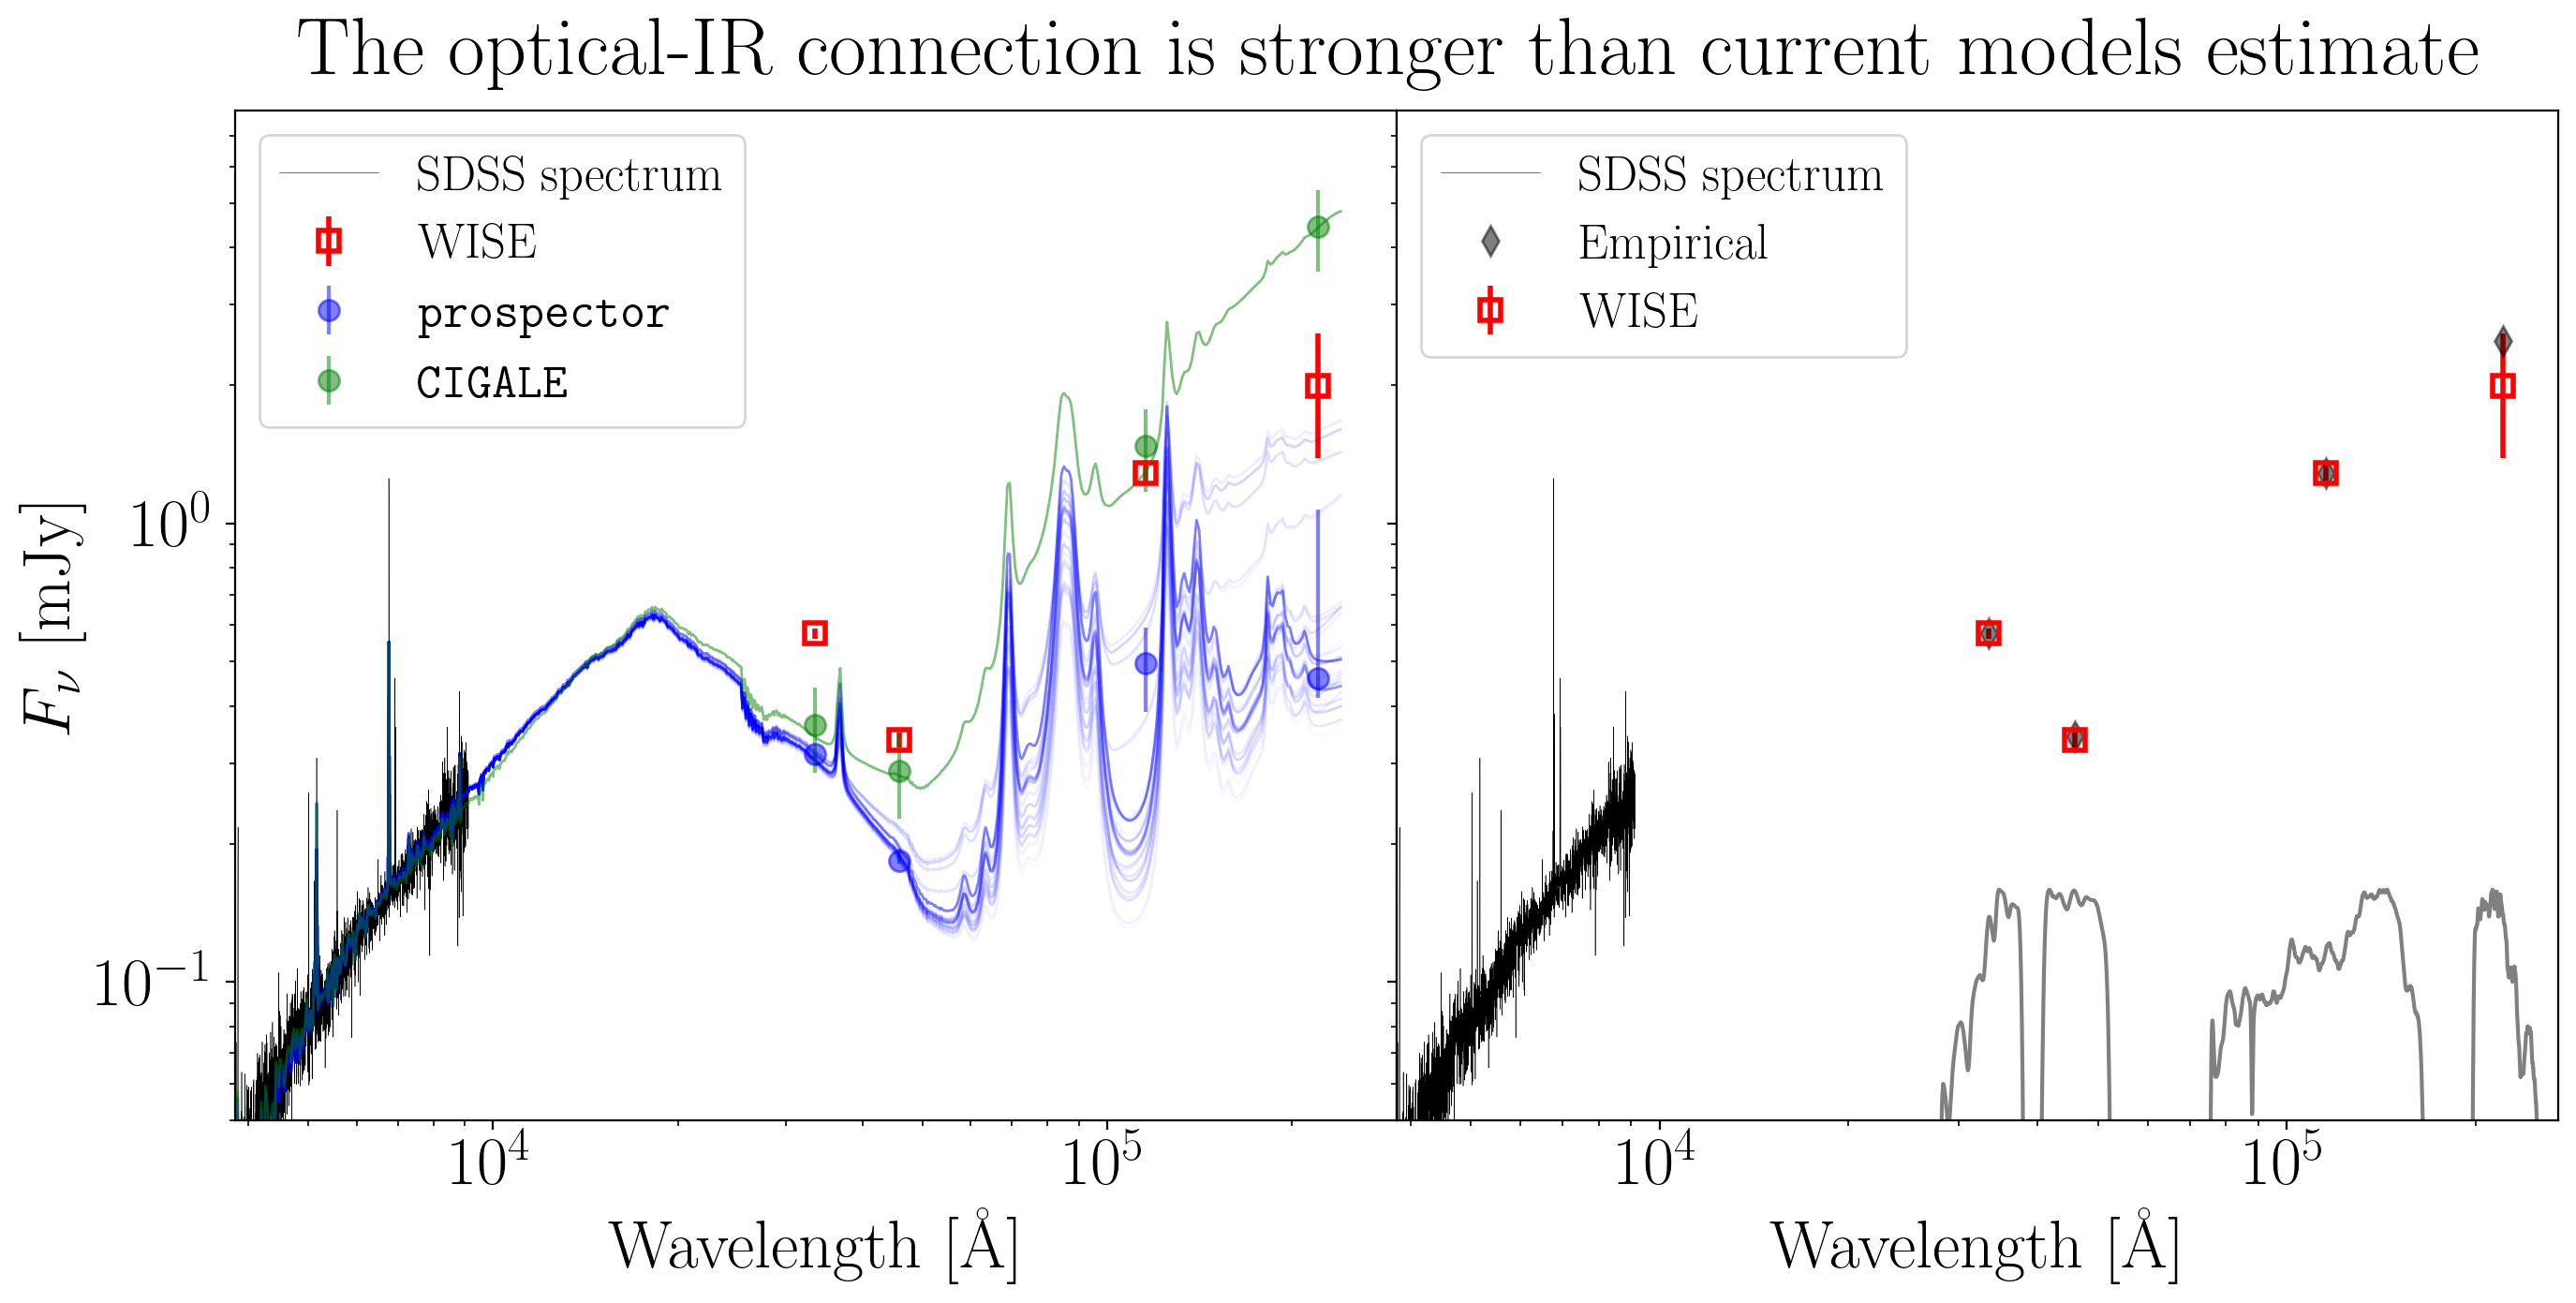

#### A little demonstration where we compare the emprical performance to the lackluster performance of two SED-fitting codes